In [ ]:
from pathlib import Path
import pandas as pd 
import numpy as np
from tqdm.auto import tqdm
import plotly.express as px
from plotly import graph_objects as go
tqdm.pandas()
from exports_utils import load_bootstrap_metrics

root = Path('/data/data/malpolon/xgb/')
inputs_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/')
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

In [2]:
fulldf = pd.read_csv(inputs_path / 'database_common.csv', index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})
species = list(fulldf.columns[-818:-1])
groundtruth = fulldf[species]

In [3]:
# Checkpoints

ind_cp_pa = '42_ind_pa_seedtest-2026-03-12_17-19'
td_cp_pa = '42_td_pa_seedtest-2026-03-11_14-31'

ind_cp_reg = '42_ind_reg_seedtest-2026-03-13_00-38'
td_cp_reg = '42_td_reg_seedtest-2026-03-12_10-21'

ind_cp_eco = '42_ind_eco_seedtest-2026-03-10_17-43'
td_cp_eco = '42_td_eco_seedtest-2026-03-10_14-13'

## P-A

#### Species F1

In [ ]:
xgb_mean, xgb_ci = load_bootstrap_metrics(output_path.parent / 'xgb', 'pa')
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_pa)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_pa)

In [ ]:
scores = [xgb_mean, ind_mean, td_mean]
errors = [xgb_ci, ind_ci, td_ci]
names = ['XGBoost', 'Deep-SDM', 'Transductive']

In [ ]:
fig = go.Figure()

colors = px.colors.qualitative.Pastel

# CI band — upper and lower as a filled trace

for i, n in enumerate(names):

    if errors[i] is not None:

        fig.add_trace(go.Scatter(
            x=np.concatenate([np.arange(400), np.arange(400)[::-1]]),
            y=np.concatenate([scores[i] + errors[i], (scores[i] - errors[i])[::-1]]),
            fill='toself',
            fillcolor=colors[i % len(colors)].replace('rgb(', 'rgba(').replace(')', ', 0.4)'),
            line=dict(color='rgba(255,255,255,0)'),  # no border line
            name='95% CI',
        ))

    # Mean curve (on top)
    fig.add_trace(go.Scatter(
        x=np.arange(400), y=np.array(scores[i]),
        mode='lines',
        line=dict(color=colors[i % len(colors)], width=3),
        name=n,
    ))

fig.update_layout(
    template='simple_white',
    width=1200, height=800,
    title='', #'Presence-absence classification',
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)

fig.show()

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores[names[0]].values, scores[names[2]].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel=names[0] + ' F1', ylabel=names[2] + ' F1')

#### Site F1

In [ ]:
sites = pd.read_csv(inputs_path / 'site_metadata.csv', index_col='site_code').dropna()

xgb_f1_site = pd.read_csv(output_path.parent / 'xgb' / 'pa' / 'f1_by_site.csv', index_col = 0)
ind_f1_site = pd.read_csv(output_path / ind_cp_pa / 'f1_by_site.csv', index_col = 0)
td_f1_site = pd.read_csv(output_path / td_cp_pa / 'f1_by_site.csv', index_col = 0)

sites['XGB'] = xgb_f1_site['mean']
sites['IND'] = ind_f1_site['mean']
sites['TD'] = td_f1_site['mean']

sites['delta'] = (sites['TD'] - sites['XGB'])

In [ ]:
import plotly.express as px

fig = px.scatter_map(sites, lat='latitude',lon='longitude', color='delta', height = 700, width = 800,
                     center={'lat':-28, 'lon':133}, zoom=3, opacity=0.5,
                     color_continuous_midpoint=0,
                     color_continuous_scale=px.colors.sequential.RdBu, map_style='dark')

fig.update_traces(marker=dict(size=20))
fig.show()

In [ ]:
(sites['delta'] / (sites['XGB']+1e-6)).describe()
(sites['TD'] - sites['IND']).describe()

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = sites['XGB'].values, sites['TD'].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='XGB F1', ylabel='TD F1')

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

sites['delta'] = sites['TD'] - sites['IND']
sites['distance_cat'] = pd.cut(sites['distance_km'], bins=[0, 50, 100, 150, 200, 300, np.inf], labels=['0-50', '50-100', '100-150', '150-200', '200-300', '300+'])

fig = px.violin(sites, x="distance_cat", y="delta", points = 'all', color = "distance_cat",
                color_discrete_sequence= px.colors.qualitative.Pastel, box = True,
                category_orders={'distance_cat': ['0-50', '50-100', '100-150', '150-200', '200-300', '300+']})


fig.update_layout(
    template='simple_white',
    width = 800, height=800,
    yaxis_title='F1 delta',
    xaxis_title='Distance to closest training point (km)',
    font=dict(size=20),
    showlegend=False)
    

fig.add_shape(type="line",
    xref="paper",
    x0=0, y0=0,
    x1=1, y1=0,
    line=dict(
        color="black",
        width=1,
    ))

fig.show()

## Reg

In [ ]:
xgb_mean, xgb_ci = load_bootstrap_metrics(output_path.parent / 'xgb', 'reg')
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_reg)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_reg)

In [ ]:
scores = [xgb_mean, ind_mean, td_mean]
errors = [xgb_ci, ind_ci, td_ci]
names = ['XGBoost', 'Deep-SDM', 'Transductive']

In [ ]:
fig = go.Figure()

colors = px.colors.qualitative.Pastel

# CI band — upper and lower as a filled trace

for i, n in enumerate(names):

    if errors[i] is not None:

        fig.add_trace(go.Scatter(
            x=np.concatenate([np.arange(400), np.arange(400)[::-1]]),
            y=np.concatenate([scores[i] + errors[i], (scores[i] - errors[i])[::-1]]),
            fill='toself',
            fillcolor=colors[i % len(colors)].replace('rgb(', 'rgba(').replace(')', ', 0.4)'),
            line=dict(color='rgba(255,255,255,0)'),  # no border line
            name='95% CI',
        ))

    # Mean curve (on top)
    fig.add_trace(go.Scatter(
        x=np.arange(400), y=np.array(scores[i]),
        mode='lines',
        line=dict(color=colors[i % len(colors)], width=3),
        name=n,
    ))

fig.update_layout(
    template='simple_white',
    width=1200, height=800,
    title='', #'Presence-absence classification',
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)

fig.show()

In [ ]:
scores['delta'] = (scores['Transductive'] - scores['XGBoost']) / (scores['XGBoost']+1e-6)
scores['delta'].describe()

## Traits based

#### Load traits

In [4]:
traits = pd.read_csv('/data/data/RLS/traits.csv', index_col=0)

class_dict = {s: traits['class'].get(s, 'Unknown') for s in species}
class_series = pd.Series(class_dict, index = species, name = 'class')

troph_level_dict = {s: traits['Troph'].get(s, np.nan) for s in species}
troph_level = pd.Series(troph_level_dict, index = species, name = 'troph_level')

importance_dict = {s: traits['Importance'].get(s, np.nan) for s in species}
importance = pd.Series(importance_dict, index = species, name = 'importance')

dempel_dict = {s: traits['DemersPelag'].get(s, np.nan) for s in species}
dempel = pd.Series(dempel_dict, index = species, name = 'dempel')

climvuln_dict = {s: traits['ClimVuln_SSP585'].get(s, np.nan) for s in species}
climvuln = pd.Series(climvuln_dict, index = species, name = 'climvuln')

uicnL_status_dict = {s: traits['IUCN_inferred_Loiseau23'].get(s, 'No Status') for s in species}
uicnL_status = pd.Series(uicnL_status_dict, index = species, name = 'uicnL_status')
uicnL_threatened = pd.Series([(uicnL_status_dict[s] == 'Threatened')*1 for s in species], index = species, name = 'Threatened')

uicn_species = list(uicnL_threatened[uicnL_threatened == 1].index)

#### Load scores to compare

In [ ]:
# P-A

xgb_mean, xgb_ci = load_bootstrap_metrics(output_path.parent / 'xgb', 'pa', reindex = False)
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_pa, reindex = False)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_pa, reindex = False)

scores = pd.concat([xgb_mean, td_mean], axis = 1)
names = ['XGB', 'Transductive']
scores.columns = names

In [8]:
scores.loc[[ 'Hypoplectrodes maccullochi', 'Kyphosus cornelii', 'Parma unifasciata', 'Mecaenichthys immaculatus']]

,Inductive,Transductive,progress_perc,progress,max,uicnL_status,troph_level,troph_level_cat,importance,dempel,climvuln
Hypoplectrodes maccullochi,0.664093,0.779496,0.173774,0.115402,0.779496,Threatened,3.55,3-4,NaN,reef-associated,0.55-7
Kyphosus cornelii,0.453444,0.630016,0.389403,0.176573,0.630016,Threatened,2.00,1-2,commercial,reef-associated,NaN
Parma unifasciata,0.666566,0.771889,0.158009,0.105324,0.771889,Threatened,2.67,2-3,NaN,reef-associated,NaN
Mecaenichthys immaculatus,0.382796,0.413289,0.079659,0.030493,0.413289,Threatened,2.00,1-2,NaN,reef-associated,NaN


In [ ]:
# # Reg

xgb_mean, xgb_ci = load_bootstrap_metrics(output_path.parent / 'xgb', 'reg', reindex = False)
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_reg, reindex = False)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_reg, reindex = False)

scores = pd.concat([xgb_mean, td_mean], axis = 1)
names = ['XGB', 'Transductive']

In [16]:
# Calculate progress

scores['progress_perc'] = (scores[names[1]] - scores[names[0]]) / (scores[names[0]] + 1e-6)
scores['progress'] = (scores[names[1]] - scores[names[0]]) 
scores['max'] = scores[names].max(axis=1)


# Add traits
scores['uicnL_status'] = uicnL_status.loc[scores.index]
scores['troph_level'] = troph_level.loc[scores.index]
scores['troph_level_cat'] = pd.cut(scores['troph_level'], bins=[1, 2, 3, 4, 5], labels=['1-2', '2-3', '3-4', '4-5'])
scores['importance'] = importance.loc[scores.index]
scores['dempel'] = dempel.loc[scores.index]
scores['climvuln'] = pd.cut(climvuln.loc[scores.index], bins=[0.3, 0.45, 0.5, 0.55, 7], labels=['0.3-0.45', '0.45-0.5', '0.5-0.55', '0.55-7'])
scores['class'] = class_series.loc[scores.index]

relevant_scores = scores.loc[scores['max'] > 0.2].copy()

<Axes: >

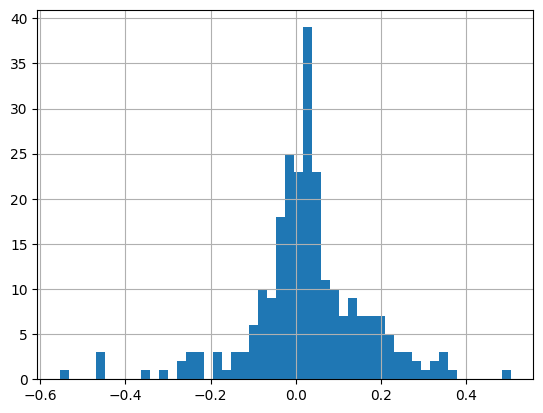

In [9]:
relevant_scores['progress'].hist(bins = 50)

#### Plot performance increase vs traits

In [17]:
t = 'class' 

fig = px.violin(relevant_scores, x=t, y="progress", points = 'all', color = t,
                color_discrete_sequence= px.colors.qualitative.Pastel, box = True)


fig.update_layout(
    template='simple_white',
    width = 800, height=800,
    yaxis_title='F1 delta',
    xaxis_title='',
    font=dict(size=20),
    showlegend=False)
    

fig.add_shape(type="line",
    xref="paper",
    x0=0, y0=0,
    x1=1, y1=0,
    line=dict(
        color="black",
        width=1,
    ))

fig.show()

In [ ]:
relevant_scores = scores.loc[scores['max'] > 0.2].copy()

print(relevant_scores.groupby('uicnL_status')['progress_perc'].describe()['50%'])
print(relevant_scores['progress_perc'].describe()['50%'])

In [ ]:
scores.sort_values(by='Transductive', ascending=False)

## Eco indicators

In [ ]:
xgb_mean, xgb_ci = load_bootstrap_metrics('/data/data/malpolon/xgb/', 'eco')
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_eco)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_eco)

tdstacked_r2 = pd.read_csv(output_path / td_cp_pa / 'eco_indic_corr.csv', index_col=0)

In [ ]:
scores = pd.concat([xgb_mean, ind_mean, td_mean, tdstacked_r2["mean"]], axis = 1)
errors = [xgb_ci, ind_ci, td_ci, None]
names = ['XGBoost', 'Deep-SDM', 'Transductive (direct)', 'Transductive (stacked)']
scores.columns = names

In [ ]:
fig = go.Figure()

colors = px.colors.qualitative.Pastel

for i, n in enumerate(names[:-1]):
    fig.add_trace(go.Bar(
        name=n,
        x=scores.index, y=scores.iloc[:,i],
        error_y=dict(type='data', array=errors[i]),
        marker_color=colors[i % len(colors)],
    ))

fig.add_trace(go.Bar(
    name=names[-1],
    x=tdstacked_r2.index, y=scores.iloc[:,-1],
    error_y=dict(type='data',
                 symmetric=False,
                 array=tdstacked_r2['max'] - scores.iloc[:,-1],
                 arrayminus=scores.iloc[:,-1] -tdstacked_r2['min']),
    marker_color=colors[len(names) -1 % len(colors)],
    ))

fig.update_layout(barmode='group',
                  width = 800, height=800,
                  template = 'simple_white',
                  title='',
                  xaxis_title='',
                  yaxis_title='Pearson R',
                  font=dict(size=20),
                  legend_title_text='',
                  legend=dict(yanchor="top",
                              y=0.99,
                              xanchor="center",
                              x=0.5),
)

fig.show()


# fig = px.bar(data, x=data['species'], y='pearsonr', color='model', template = 'simple_white', barmode='group',
#            width = 800, height=800,
#            )


## Any 2

#### 1v1 BlandAltman

In [ ]:
import pyCompare

pyCompare.blandAltman(scores[names[2]].values,scores[names[0]].values)

#### 1v1 Scatter plot

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores[names[0]].values, scores[names[2]].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel=names[0] + ' F1', ylabel=names[2] + ' F1')

#### 1v1 arrow scatter

In [ ]:
(relevant_scores['Transductive'] - relevant_scores['XGB']).hist(bins=40)

relevant_scores.sort_values(by='XGB', ascending=False, inplace=True)
relevant_scores['x'] = np.arange(len(relevant_scores))

In [ ]:
# Example data
x = relevant_scores['x']
y1 = relevant_scores['XGB']
y2 = relevant_scores['Transductive']
hover_text = relevant_scores.index.to_list()

# Create the figure
fig = go.Figure()

# Add the two series as scatter plots
fig.add_trace(go.Scatter(
    x=x, y=y1,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[0], size=10),
    name='XGBoost',
    hovertext=hover_text,
    hoverinfo='text'
))

fig.add_trace(go.Scatter(
    x=x, y=y2,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[3], size=10),
    name='Transductive',
    hovertext=hover_text,
    hoverinfo='text'
))

# Add arrows for the differences
for i in range(len(x)):
    fig.add_annotation(
        ax=x[i], ay=y1[i],
        axref='x', ayref='y',
        x=x[i], y=y2[i],
        xref='x', yref='y',
        showarrow=True,
        arrowhead=1,
        arrowsize=1.5,
        arrowcolor=px.colors.qualitative.Pastel1[1],
        arrowwidth=1.5,
    )


fig.update_layout(
    template='simple_white',
    width = 1200, height=800,
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)
